# EDA Visualizations

This notebook generates all EDA images and saves them to `../data/images/`.  
Run this notebook **after** notebooks 1, 2, and 3 so that the `.pkl` files already exist.

Images generated:
1. `job_distribution.png`
2. `class_balance.png`
3. `text_length_distribution.png`
4. `skills_frequency.png`
5. `wordcloud_skills.png`
6. `tfidf_variance.png`
7. `model_comparison.png`
8. `confusion_matrix_best_model.png`
9. `feature_importance.png`
10. `certifications_frequency.png`

## 0. Setup

In [1]:
import os
import re
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

# ── Output directory ──────────────────────────────────────────
IMG_DIR = '../data/images'
os.makedirs(IMG_DIR, exist_ok=True)

# ── Global style (moderne & épuré) ────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'font.family':       'DejaVu Sans',
    'figure.facecolor':  '#fafafa',
    'axes.facecolor':    '#fafafa',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.7,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.bottom':      False,
    'ytick.left':        False,
})

# Palette Rouge/Rose
PRIMARY   = '#c0392b'   # rouge foncé (accents, lignes de référence)
CMAP_HEAT = 'Reds'

print('Setup complete. Images will be saved to:', os.path.abspath(IMG_DIR))

Setup complete. Images will be saved to: c:\Users\DELL\OneDrive\Bureau\Job-Roles-Prediction - Copie\data\images


## 1. Load data

In [2]:
# Raw CSV
df = pd.read_csv('../data/csv/jobs.csv', sep=';', encoding='utf-8')

# Preprocessed data (from notebook 1)
with open('../data/pkl/preprocessed_data.pkl', 'rb') as f:
    pre = pickle.load(f)
df_clean      = pre['df_clean']
label_encoder = pre['label_encoder']

# Feature sets (from notebook 2)
with open('../data/pkl/feature_sets.pkl', 'rb') as f:
    feat = pickle.load(f)
svd              = feat['svd']
tfidf_vectorizer = feat['tfidf_vectorizer']

# Modeling results (from notebook 3)
with open('../data/pkl/modeling_results_gridsearch.pkl', 'rb') as f:
    res = pickle.load(f)
results_df       = res['all_results']
best_model       = res['best_model']
best_predictions = res['best_predictions']
y_test           = res['y_test']

print('Data loaded successfully.')
print(f'  Raw dataset   : {df.shape[0]} rows, {df.shape[1]} columns')
print(f'  Clean dataset : {df_clean.shape[0]} rows')
print(f'  Job titles    : {df["Job Title"].nunique()} unique classes')

Data loaded successfully.
  Raw dataset   : 2458 rows, 4 columns
  Clean dataset : 2458 rows
  Job titles    : 119 unique classes


## 2. APERÇU GÉNÉRAL DES DONNÉES

In [3]:
print("Nombre total de lignes:",
       df.shape[0])
print("Nombre de colonnes:", 
      df.shape[1])
print("\nLes nom des colonne:")
print(df.columns)
print("\nTypes de données de chaque colonne:")
print(df.dtypes)
print("\nAperçu des premières lignes:")
print(df.head())
print("\nAperçu des dernières lignes:")
print(df.tail())
print("\nStatistiques descriptives:")
print(df.describe())

Nombre total de lignes: 2458
Nombre de colonnes: 4

Les nom des colonne:
Index(['Job Title', 'Skills', 'Job Description', 'Certifications'], dtype='object')

Types de données de chaque colonne:
Job Title          object
Skills             object
Job Description    object
Certifications     object
dtype: object

Aperçu des premières lignes:
           Job Title                                    Skills  \
0  Software Engineer      Java;Spring Boot;MySQL;Git;REST APIs   
1  Software Engineer    Python;Django;PostgreSQL;Git;REST APIs   
2  Software Engineer  C#;.NET Core;SQL Server;Azure DevOps;OOP   
3  Software Engineer            Java;Hibernate;Maven;JUnit;Git   
4  Software Engineer            Python;Flask;SQLite;Docker;Git   

                                     Job Description  \
0  Conçoit et développe des applications backend ...   
1  Developpe des services web evolutifs et assure...   
2  Participe à la conception et au développement ...   
3  Implémente des fonctionnalités bac

## 3. ANALYSE DE LA QUALITÉ DES DONNÉES

In [4]:
# Nombre et pourcentage de NaN par colonne
missing = pd.DataFrame({    'Nombre_NaN': df.isnull().sum(),    'Pourcentage_NaN': round(df.isnull().sum() / len(df) * 100, 2)})
print("Nombre et pourcentage de NaN par colonne:")
print(missing[missing['Nombre_NaN'] > 0])  

Nombre et pourcentage de NaN par colonne:
Empty DataFrame
Columns: [Nombre_NaN, Pourcentage_NaN]
Index: []


In [5]:
print("\n2.2 DOUBLONS\n")
# Nombre de lignes dupliquées (complètes)
full_duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées complètes: {full_duplicates}")
print(f"Pourcentage: {round(full_duplicates / len(df) * 100, 2)}%")
# Doublons partiels : même job_title + skills, mais description différente
# D'abord, identifions les groupes avec doublons sur job_title + skills
partial_mask = df.duplicated(subset=['Job Title', 'Skills'], keep=False)
partial_duplicates_count = partial_mask.sum()
print(f"Nombre de lignes avec doublons partiels (même Job Title + Skills): {partial_duplicates_count}")
# Détail : Comptons les vrais "doublons partiels" (même title+skills, desc différente)
def count_partial_dups(group):    
    if len(group) > 1 and group['Job Description'].nunique() > 1:       
         return len(group)    
    return 0
partial_dups_by_group = df[partial_mask].groupby(['Job Title', 'Skills']).apply(count_partial_dups).sum()
print(f"Nombre de lignes avec doublons partiels (title+Skills identiques, desc différente): {int(partial_dups_by_group)}")
# Viz : Exemples de doublons partiel
examples = df[partial_mask][['Job Title', 'Skills', 'Job Description']].drop_duplicates(subset=['Job Title', 'Skills']).head()
print("\nExemples de doublons partiels:")
print(examples)


2.2 DOUBLONS

Nombre de lignes dupliquées complètes: 5
Pourcentage: 0.2%
Nombre de lignes avec doublons partiels (même Job Title + Skills): 309
Nombre de lignes avec doublons partiels (title+Skills identiques, desc différente): 303

Exemples de doublons partiels:
              Job Title                                Skills  \
101  Software Developer  Node.js;TypeScript;Git;REST APIs;SQL   
256       Web Developer       JavaScript;Node.js;HTML;CSS;Git   
258       Web Developer              PHP;Laravel;HTML;CSS;Git   
259       Web Developer         JavaScript;React;HTML;CSS;Git   
260       Web Developer           HTML;CSS;JavaScript;SEO;Git   

                                       Job Description  
101              Développe des services backend typés.  
256          Développe des applications web complètes.  
258  Développe des applications web backend et fron...  
259         Développe des interfaces web interactives.  
260           Optimise le référencement des sites web.  


## 4. Image 1 — Top 20 Job Title Distribution

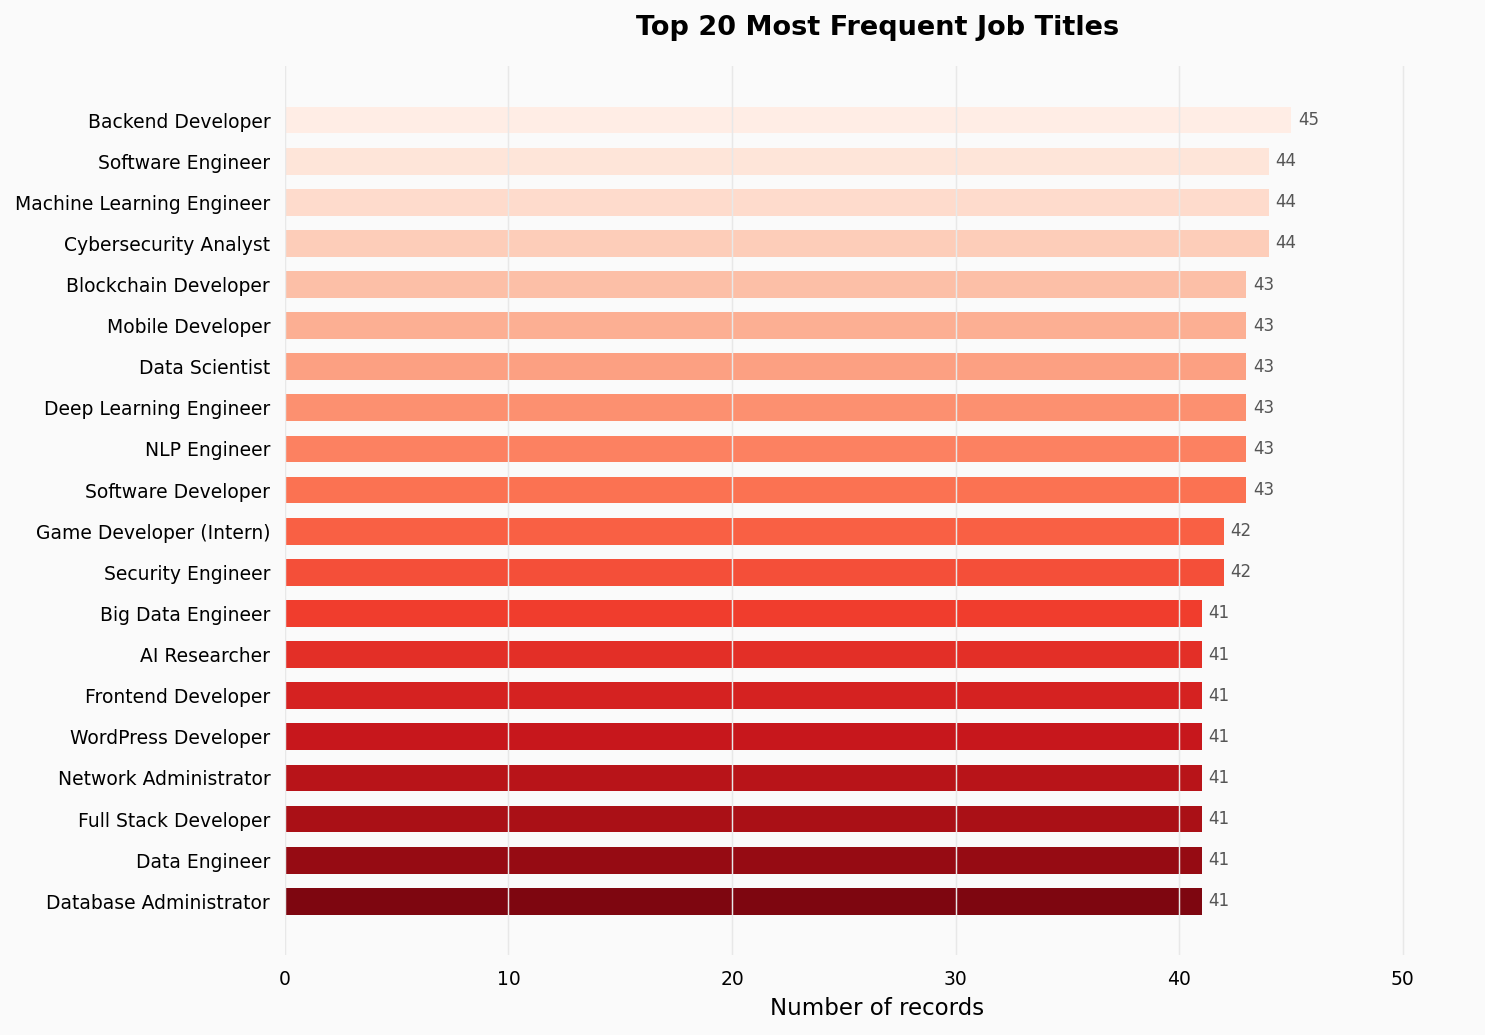

Saved: ../data/images/job_distribution.png


In [6]:
top20 = df['Job Title'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Reds_r', 20)
bars = ax.barh(
    top20.index[::-1],
    top20.values[::-1],
    color=colors,
    edgecolor='none',
    height=0.65
)

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8, color='#555')

ax.set_xlabel('Number of records')
ax.set_title('Top 20 Most Frequent Job Titles', fontweight='bold', pad=15)
ax.set_xlim(0, top20.max() + 8)
ax.grid(axis='y', visible=False)

plt.tight_layout()
path = f'{IMG_DIR}/job_distribution.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 5. Image 2 — Class Balance (all 119 classes)

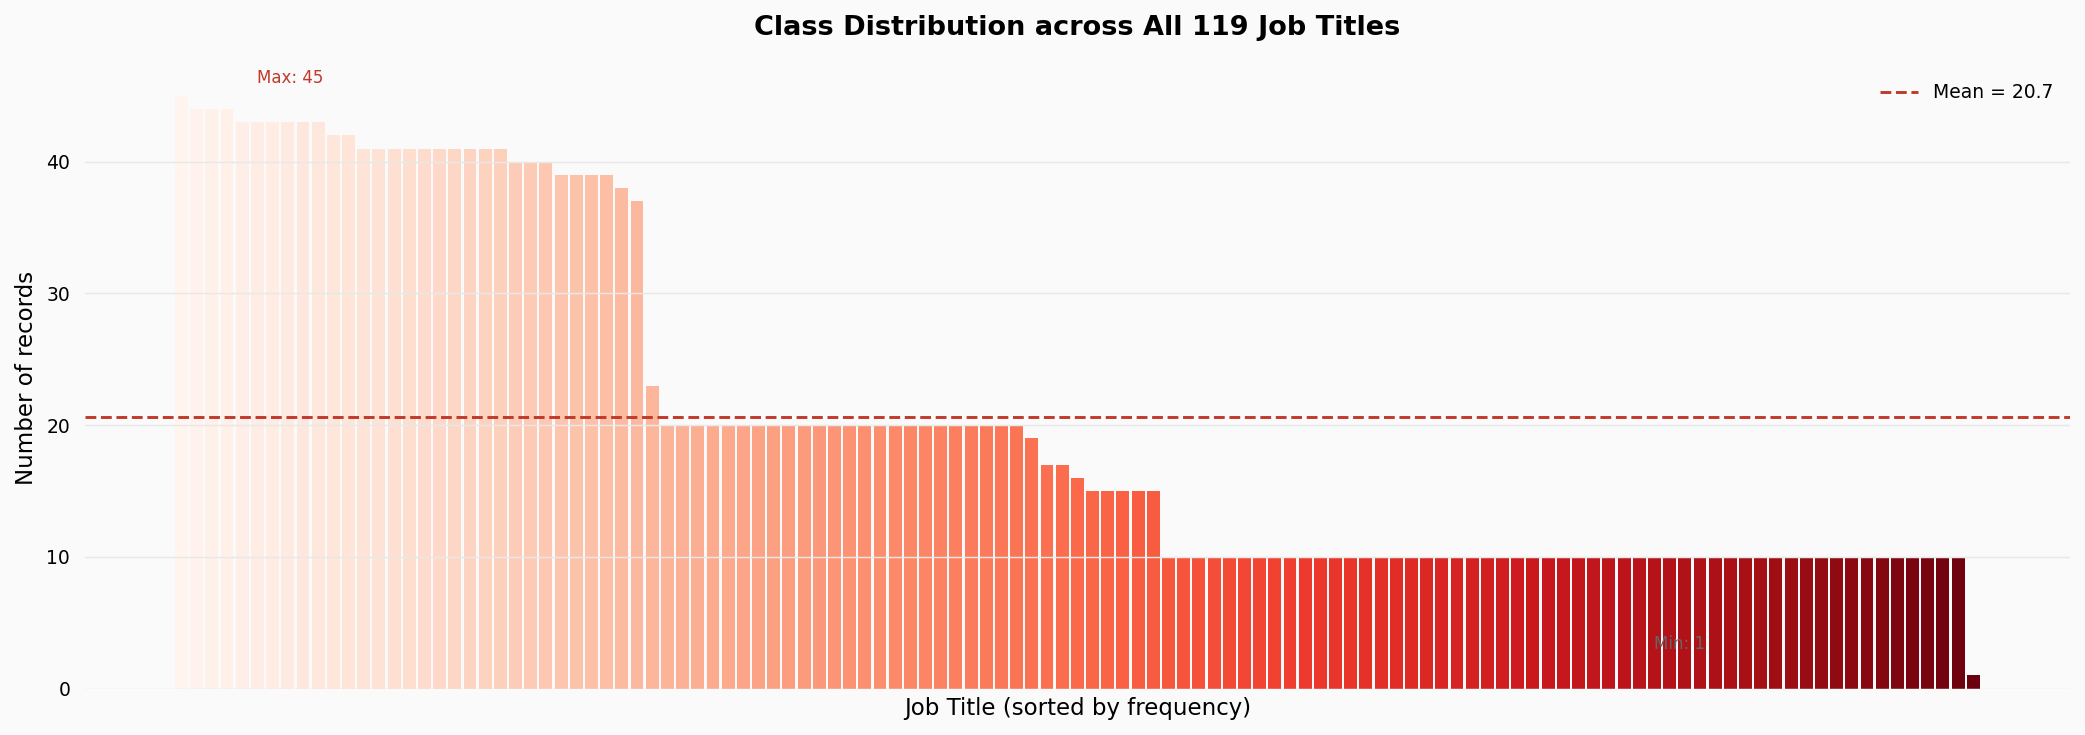

Saved: ../data/images/class_balance.png


In [7]:
counts = df['Job Title'].value_counts().reset_index()
counts.columns = ['Job Title', 'Count']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(counts)), counts['Count'],
       color=sns.color_palette('Reds', len(counts)),
       width=0.85, edgecolor='none')

mean_count = counts['Count'].mean()
ax.axhline(mean_count, color=PRIMARY, linewidth=1.4,
           linestyle='--', label=f'Mean = {mean_count:.1f}')

ax.set_xlabel('Job Title (sorted by frequency)')
ax.set_ylabel('Number of records')
ax.set_title('Class Distribution across All 119 Job Titles', fontweight='bold', pad=15)
ax.set_xticks([])
ax.legend(fontsize=9, frameon=False)

ax.annotate(f'Max: {counts["Count"].max()}',
            xy=(0, counts['Count'].max()),
            xytext=(5, counts['Count'].max() + 1),
            fontsize=8, color=PRIMARY)
ax.annotate(f'Min: {counts["Count"].min()}',
            xy=(len(counts)-1, counts['Count'].min()),
            xytext=(len(counts)-22, counts['Count'].min() + 2),
            fontsize=8, color='#666')

plt.tight_layout()
path = f'{IMG_DIR}/class_balance.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 6. Image 3 — Text Length Distribution

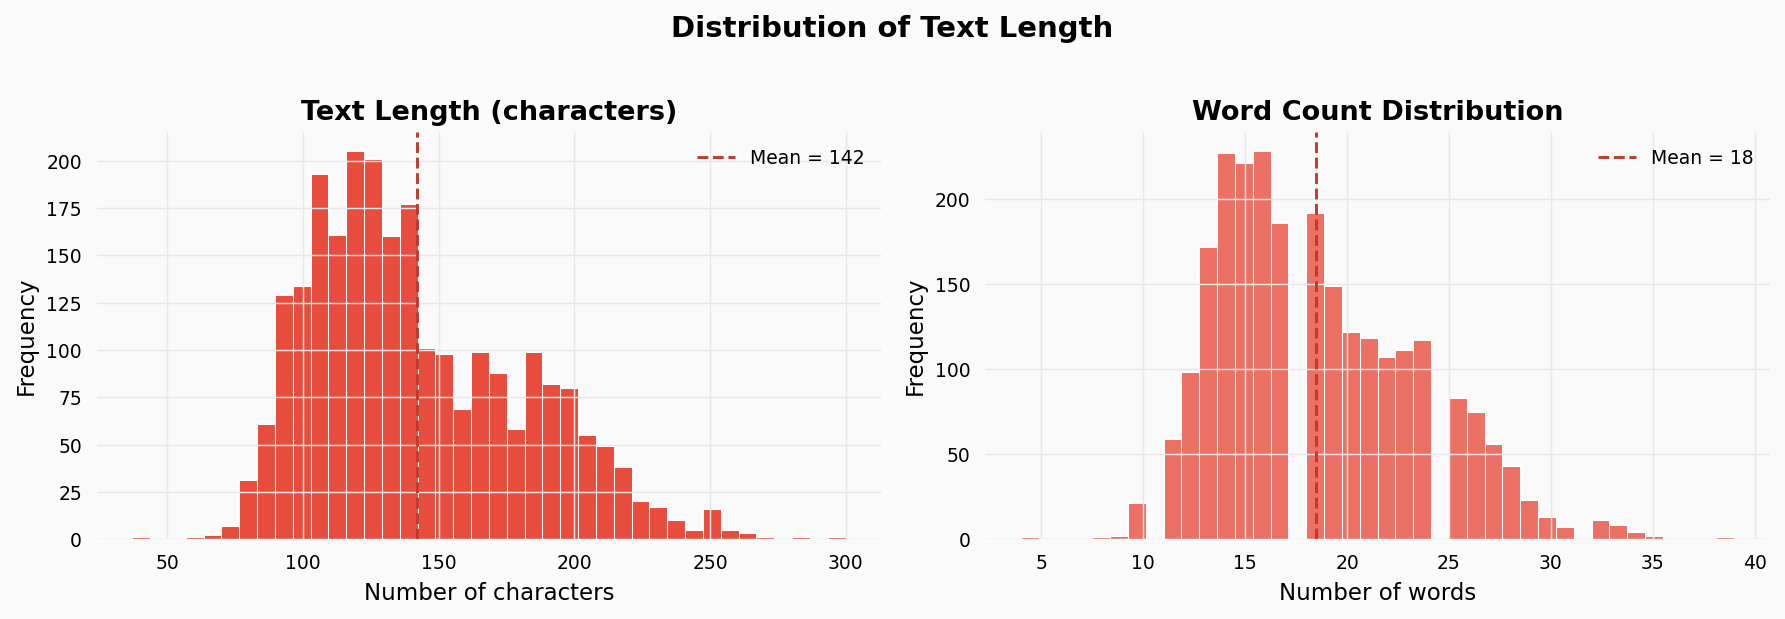

Saved: ../data/images/text_length_distribution.png


In [8]:
df_clean['text_length'] = df_clean['Combined_Text'].apply(len)
df_clean['word_count']  = df_clean['Combined_Text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Character length
axes[0].hist(df_clean['text_length'], bins=40,
             color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_clean['text_length'].mean(), color=PRIMARY,
                linestyle='--', linewidth=1.4,
                label=f'Mean = {df_clean["text_length"].mean():.0f}')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length (characters)', fontweight='bold')
axes[0].legend(fontsize=9, frameon=False)

# Word count
axes[1].hist(df_clean['word_count'], bins=40,
             color='#ec7063', edgecolor='white', linewidth=0.5)
axes[1].axvline(df_clean['word_count'].mean(), color=PRIMARY,
                linestyle='--', linewidth=1.4,
                label=f'Mean = {df_clean["word_count"].mean():.0f}')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].legend(fontsize=9, frameon=False)

fig.suptitle('Distribution of Text Length', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
path = f'{IMG_DIR}/text_length_distribution.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 7. Image 4 — Top 30 Skills Frequency

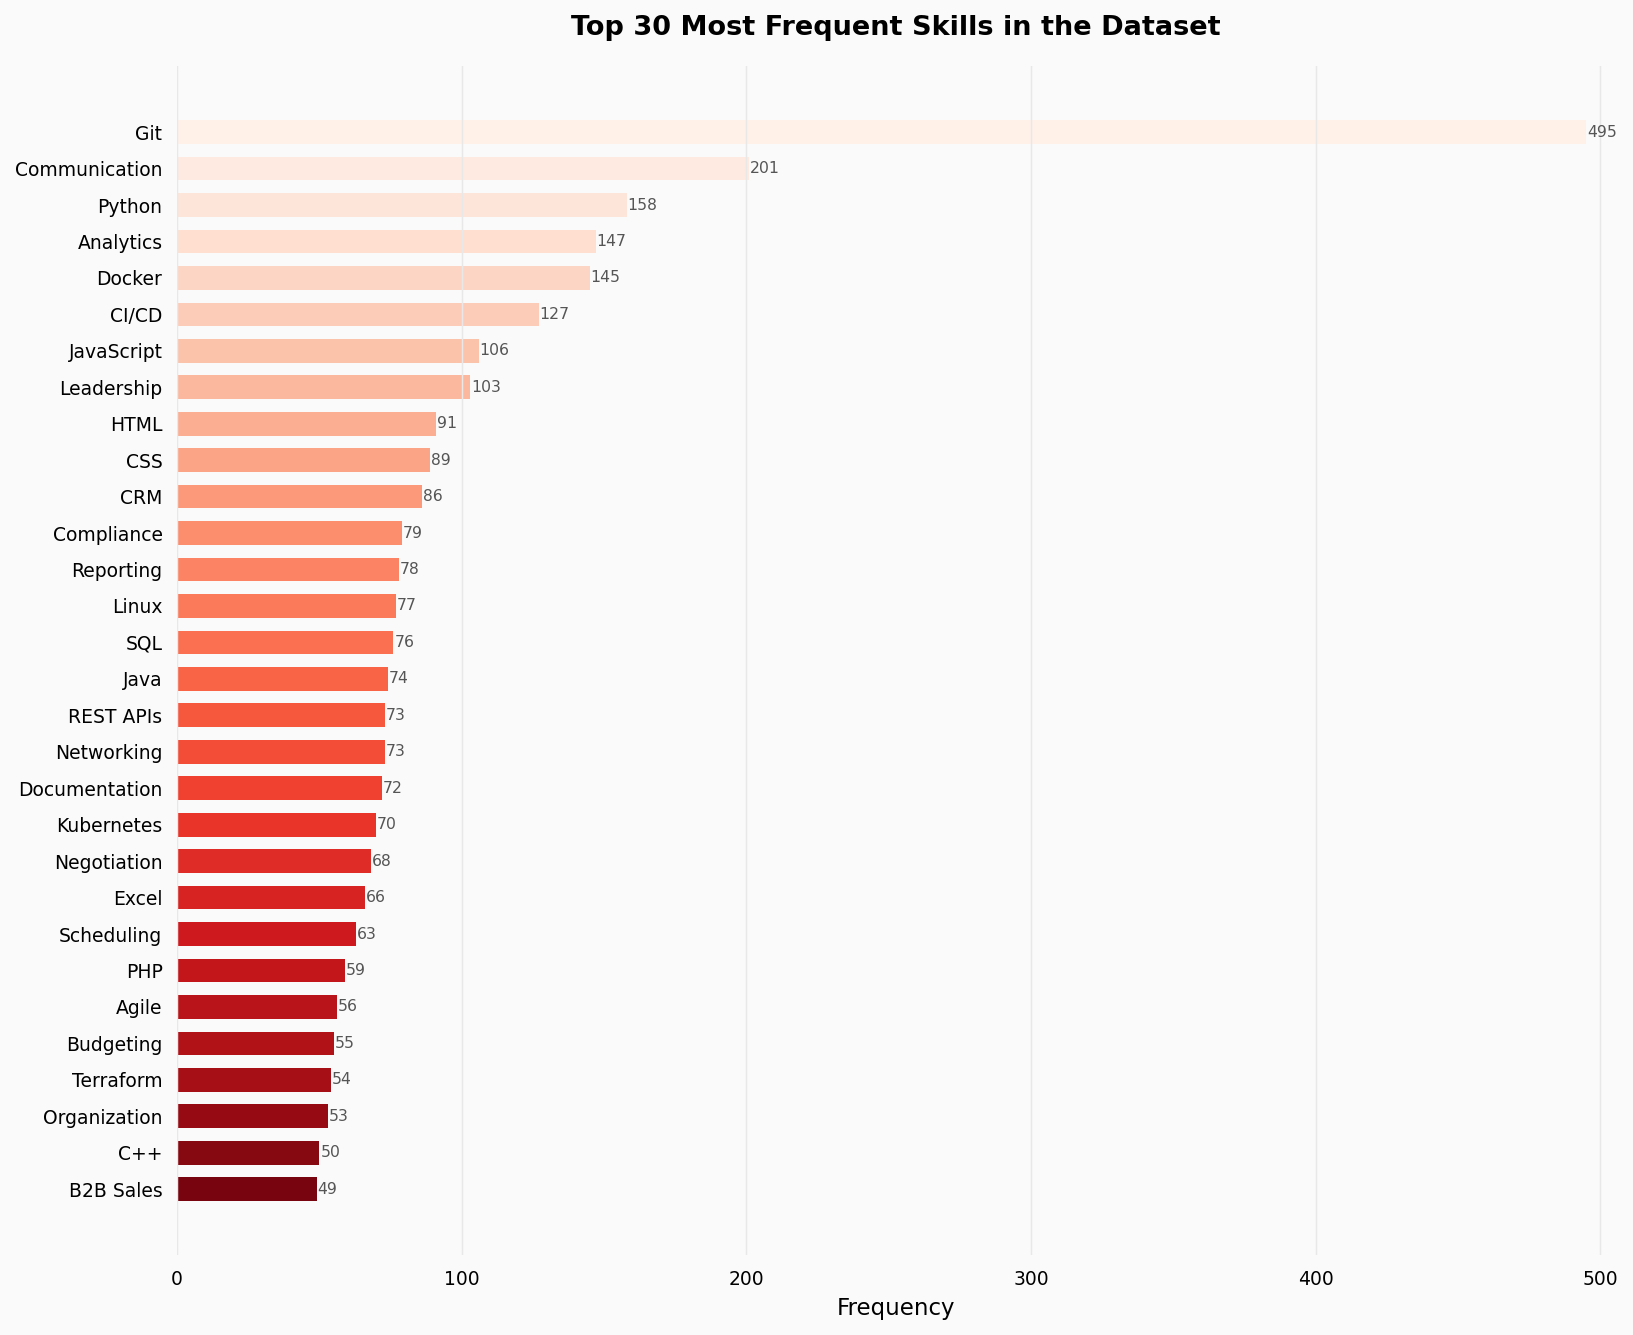

Saved: ../data/images/skills_frequency.png


In [9]:
all_skills = []
for row in df['Skills'].dropna():
    for skill in str(row).split(';'):
        s = skill.strip()
        if s:
            all_skills.append(s)

skill_counts = Counter(all_skills).most_common(30)
skills_df    = pd.DataFrame(skill_counts, columns=['Skill', 'Count'])

fig, ax = plt.subplots(figsize=(11, 9))
colors = sns.color_palette('Reds_r', 30)
bars   = ax.barh(skills_df['Skill'][::-1], skills_df['Count'][::-1],
                 color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, skills_df['Count'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=7.5, color='#555')

ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Skills in the Dataset', fontweight='bold', pad=15)
ax.set_xlim(0, skills_df['Count'].max() + 10)
ax.grid(axis='y', visible=False)

plt.tight_layout()
path = f'{IMG_DIR}/skills_frequency.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 8. Image 5 — Word Cloud of Skills

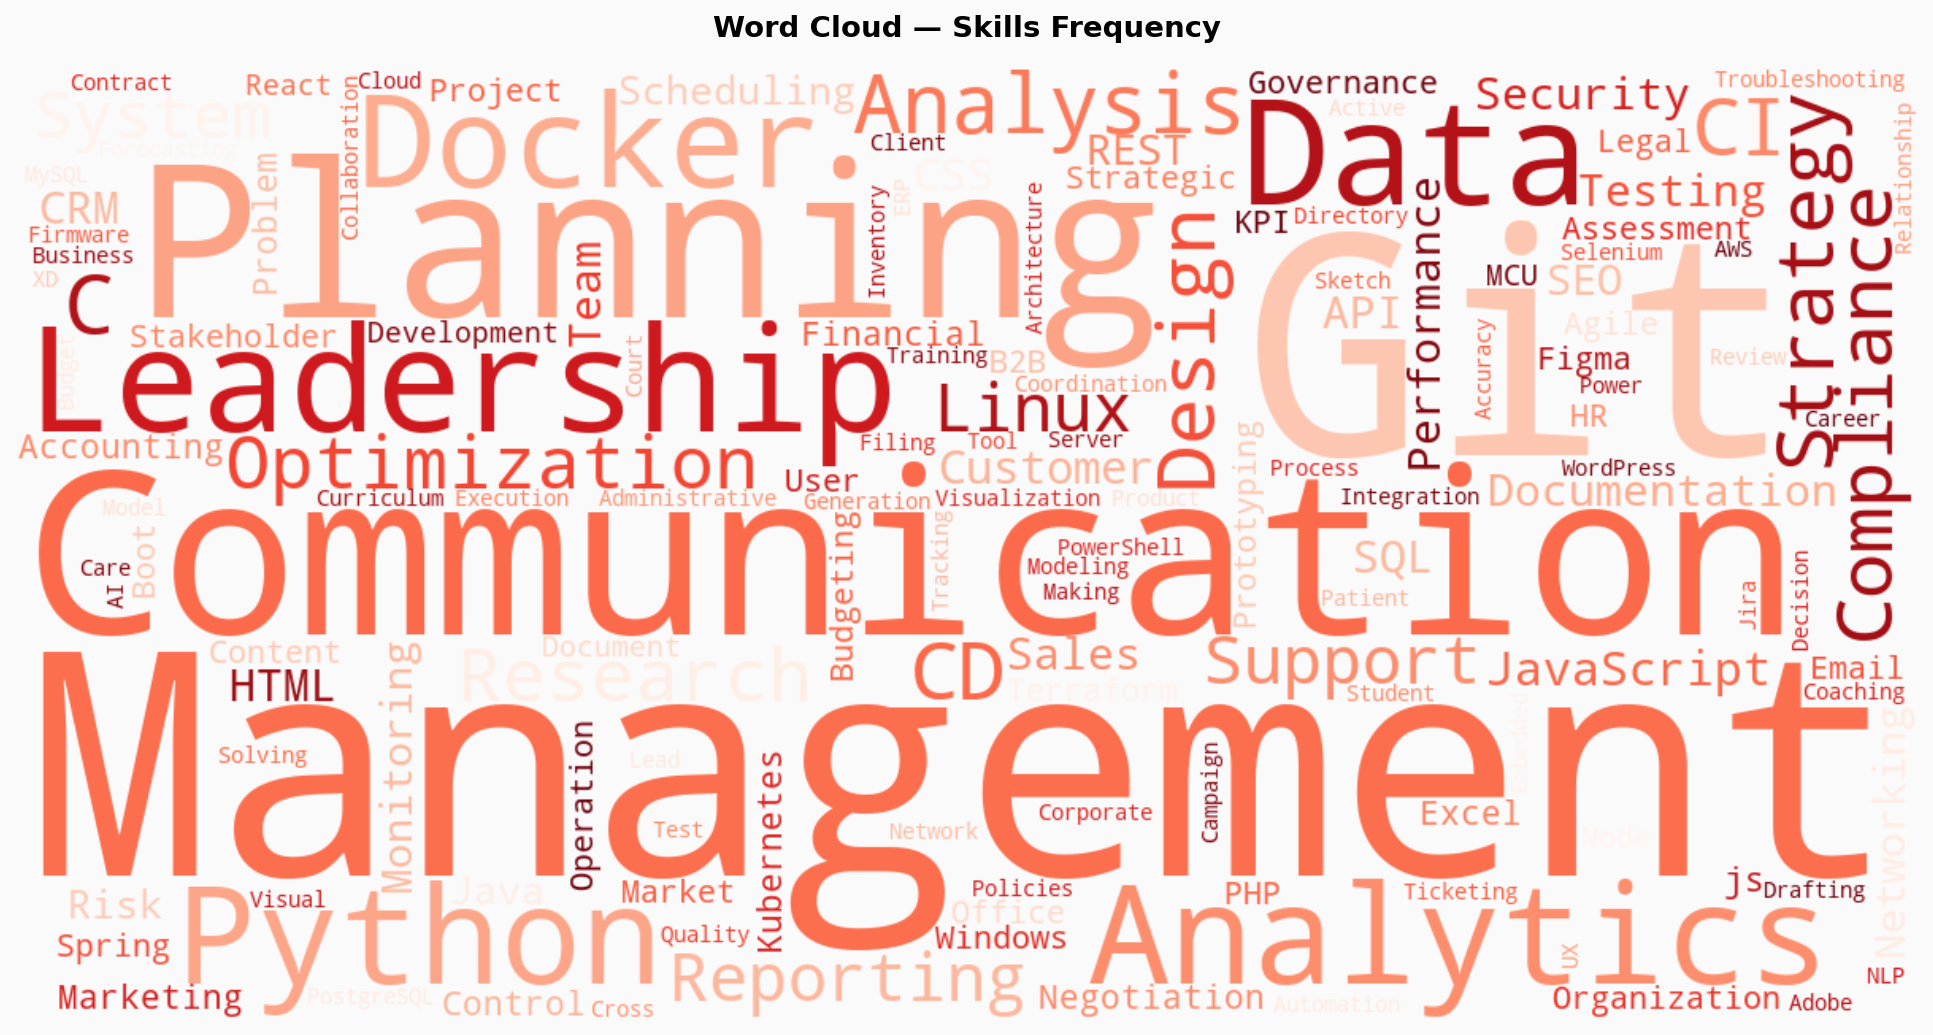

Saved: ../data/images/wordcloud_skills.png


In [10]:
try:
    from wordcloud import WordCloud

    text = ' '.join(all_skills)
    wc = WordCloud(
        width=1200, height=600,
        background_color='#fafafa',
        colormap='Reds',
        max_words=150,
        prefer_horizontal=0.85,
        collocations=False
    ).generate(text)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud — Skills Frequency', fontweight='bold', fontsize=14, pad=15)

    plt.tight_layout()
    path = f'{IMG_DIR}/wordcloud_skills.png'
    plt.savefig(path, facecolor='#fafafa')
    plt.show()
    print(f'Saved: {path}')

except ImportError:
    print('wordcloud not installed. Run: pip install wordcloud')
    print('Skipping this image.')

## 9. Image 6 — TF-IDF / SVD Explained Variance

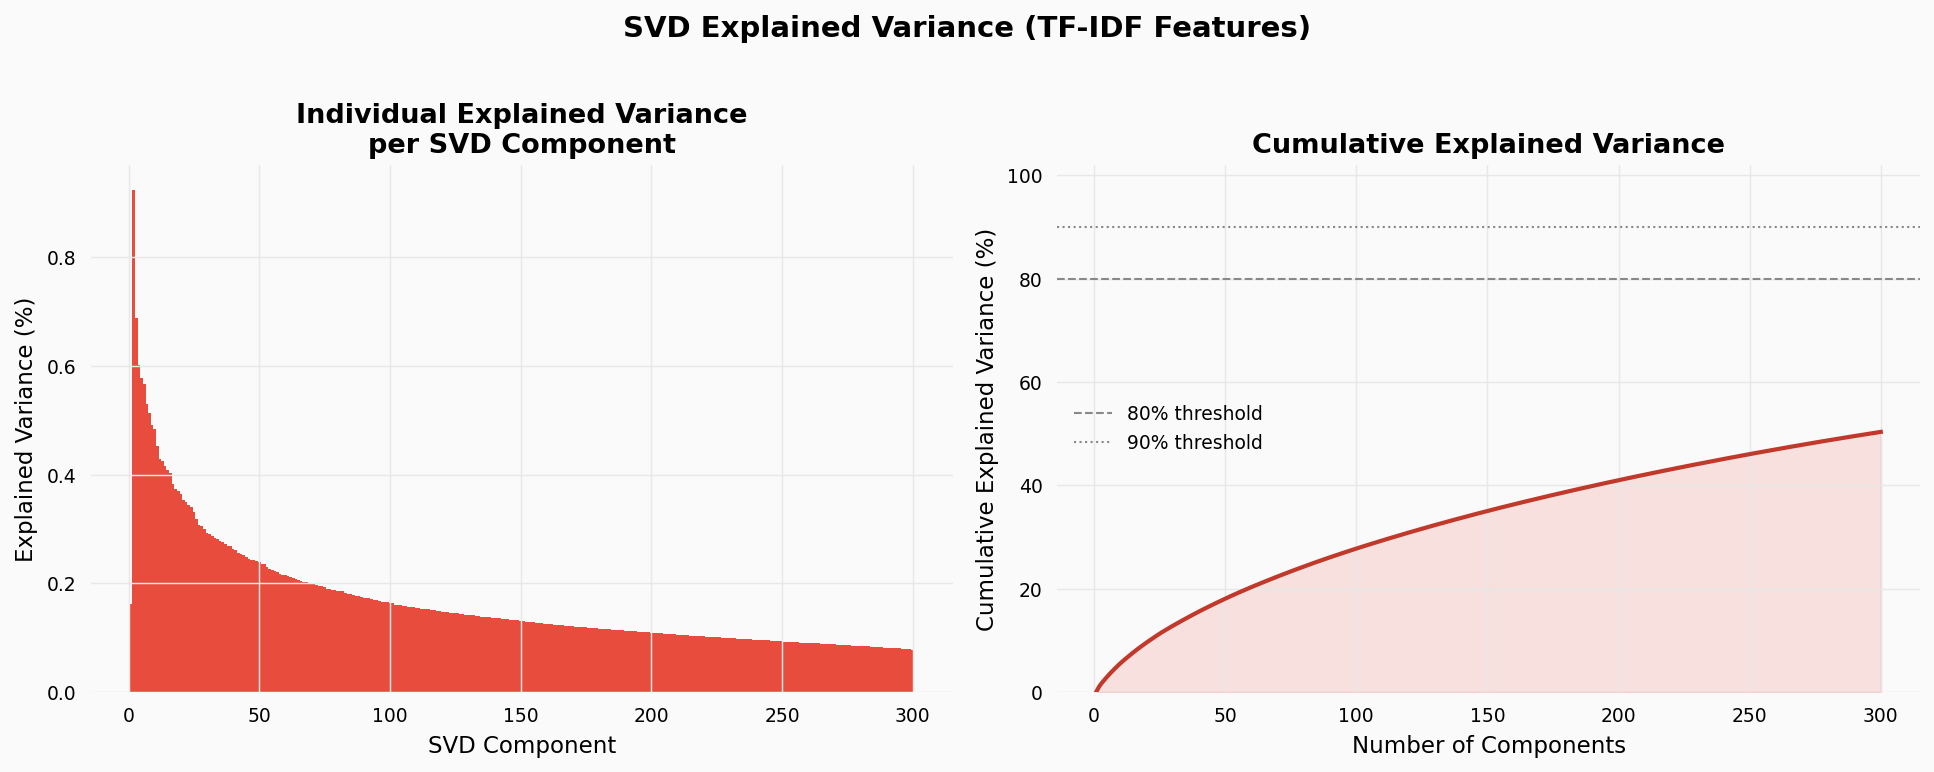

Total variance explained by 300 components: 50.35%
Saved: ../data/images/tfidf_variance.png


In [11]:
explained   = svd.explained_variance_ratio_
cumulative  = np.cumsum(explained)
components  = range(1, len(explained) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance
axes[0].bar(components, explained * 100,
            color='#e74c3c', edgecolor='none', width=1.0)
axes[0].set_xlabel('SVD Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance\nper SVD Component', fontweight='bold')

# Cumulative variance
axes[1].plot(components, cumulative * 100,
             color='#c0392b', linewidth=2)
axes[1].fill_between(components, cumulative * 100,
                     alpha=0.15, color='#e74c3c')

for threshold, ls in [(80, '--'), (90, ':')]:
    axes[1].axhline(threshold, color='#888', linestyle=ls, linewidth=1,
                    label=f'{threshold}% threshold')

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend(fontsize=9, frameon=False)
axes[1].set_ylim(0, 102)

fig.suptitle('SVD Explained Variance (TF-IDF Features)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
path = f'{IMG_DIR}/tfidf_variance.png'
plt.savefig(path)
plt.show()
print(f'Total variance explained by {len(explained)} components: {cumulative[-1]:.2%}')
print(f'Saved: {path}')

## 10. Image 7 — Model Comparison (F1-Score)

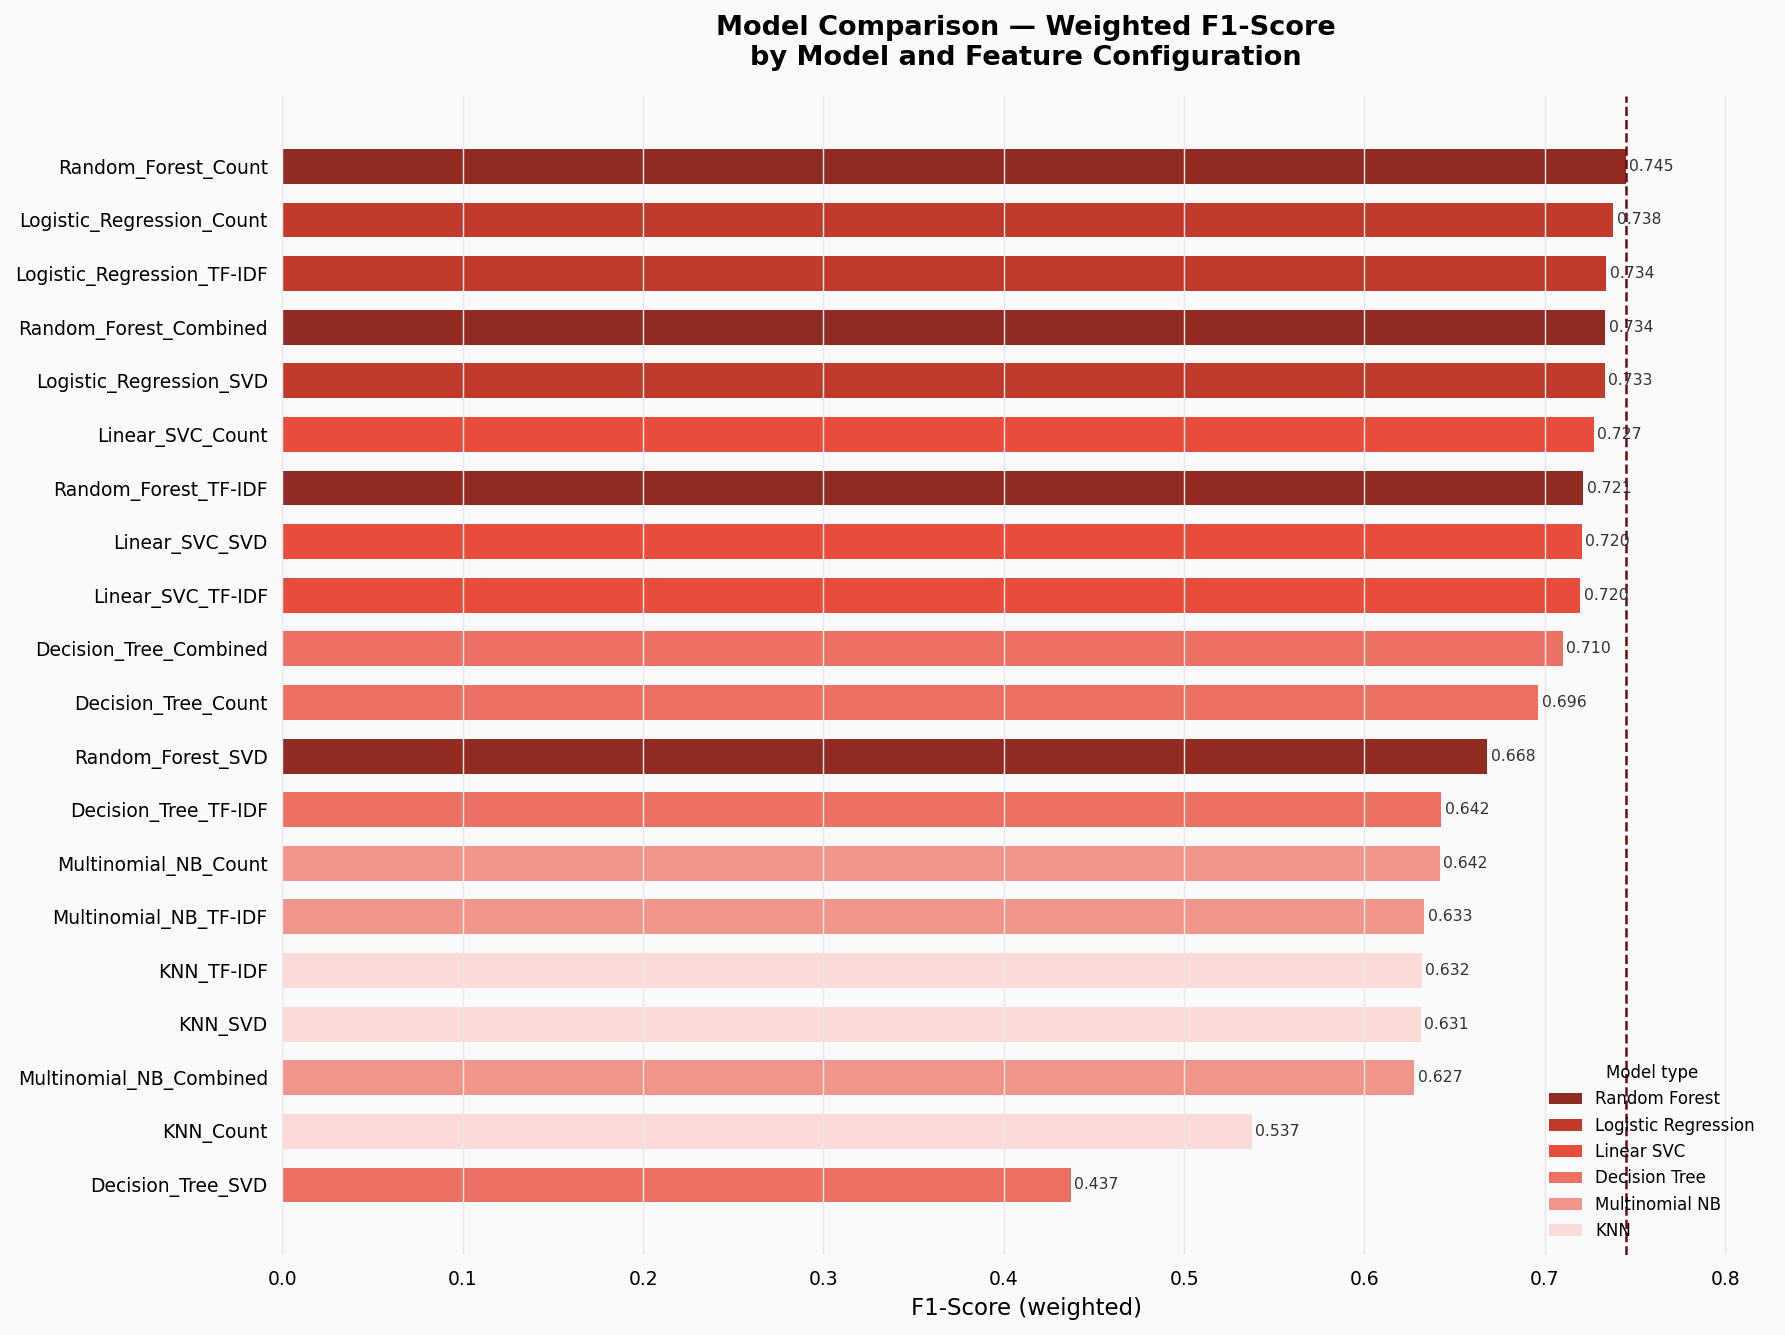

Saved: ../data/images/model_comparison.png


In [12]:
plot_df = results_df.sort_values('f1_weighted', ascending=True).copy()

# Nuances de rouge selon le type de modèle
model_colors = {
    'Random_Forest':       '#922b21',
    'Logistic_Regression': '#c0392b',
    'Linear_SVC':          '#e74c3c',
    'Decision_Tree':       '#ec7063',
    'Multinomial_NB':      '#f1948a',
    'KNN':                 '#fadbd8',
}
bar_colors = [model_colors.get(m, '#ddd') for m in plot_df['model_name']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(plot_df['combination'], plot_df['f1_weighted'],
               color=bar_colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, plot_df['f1_weighted']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=7.5, color='#333')

best_val = plot_df['f1_weighted'].max()
ax.axvline(best_val, color='#6b0e0e', linestyle='--', linewidth=1.2,
           label=f'Best = {best_val:.3f}')

ax.set_xlabel('F1-Score (weighted)')
ax.set_title('Model Comparison — Weighted F1-Score\nby Model and Feature Configuration',
             fontweight='bold', pad=15)
ax.set_xlim(0, best_val + 0.08)
ax.grid(axis='y', visible=False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m.replace('_', ' '))
                   for m, c in model_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Model type', title_fontsize=8, frameon=False)

plt.tight_layout()
path = f'{IMG_DIR}/model_comparison.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 11. Image 8 — Confusion Matrix (Best Model, Top 20 Classes)

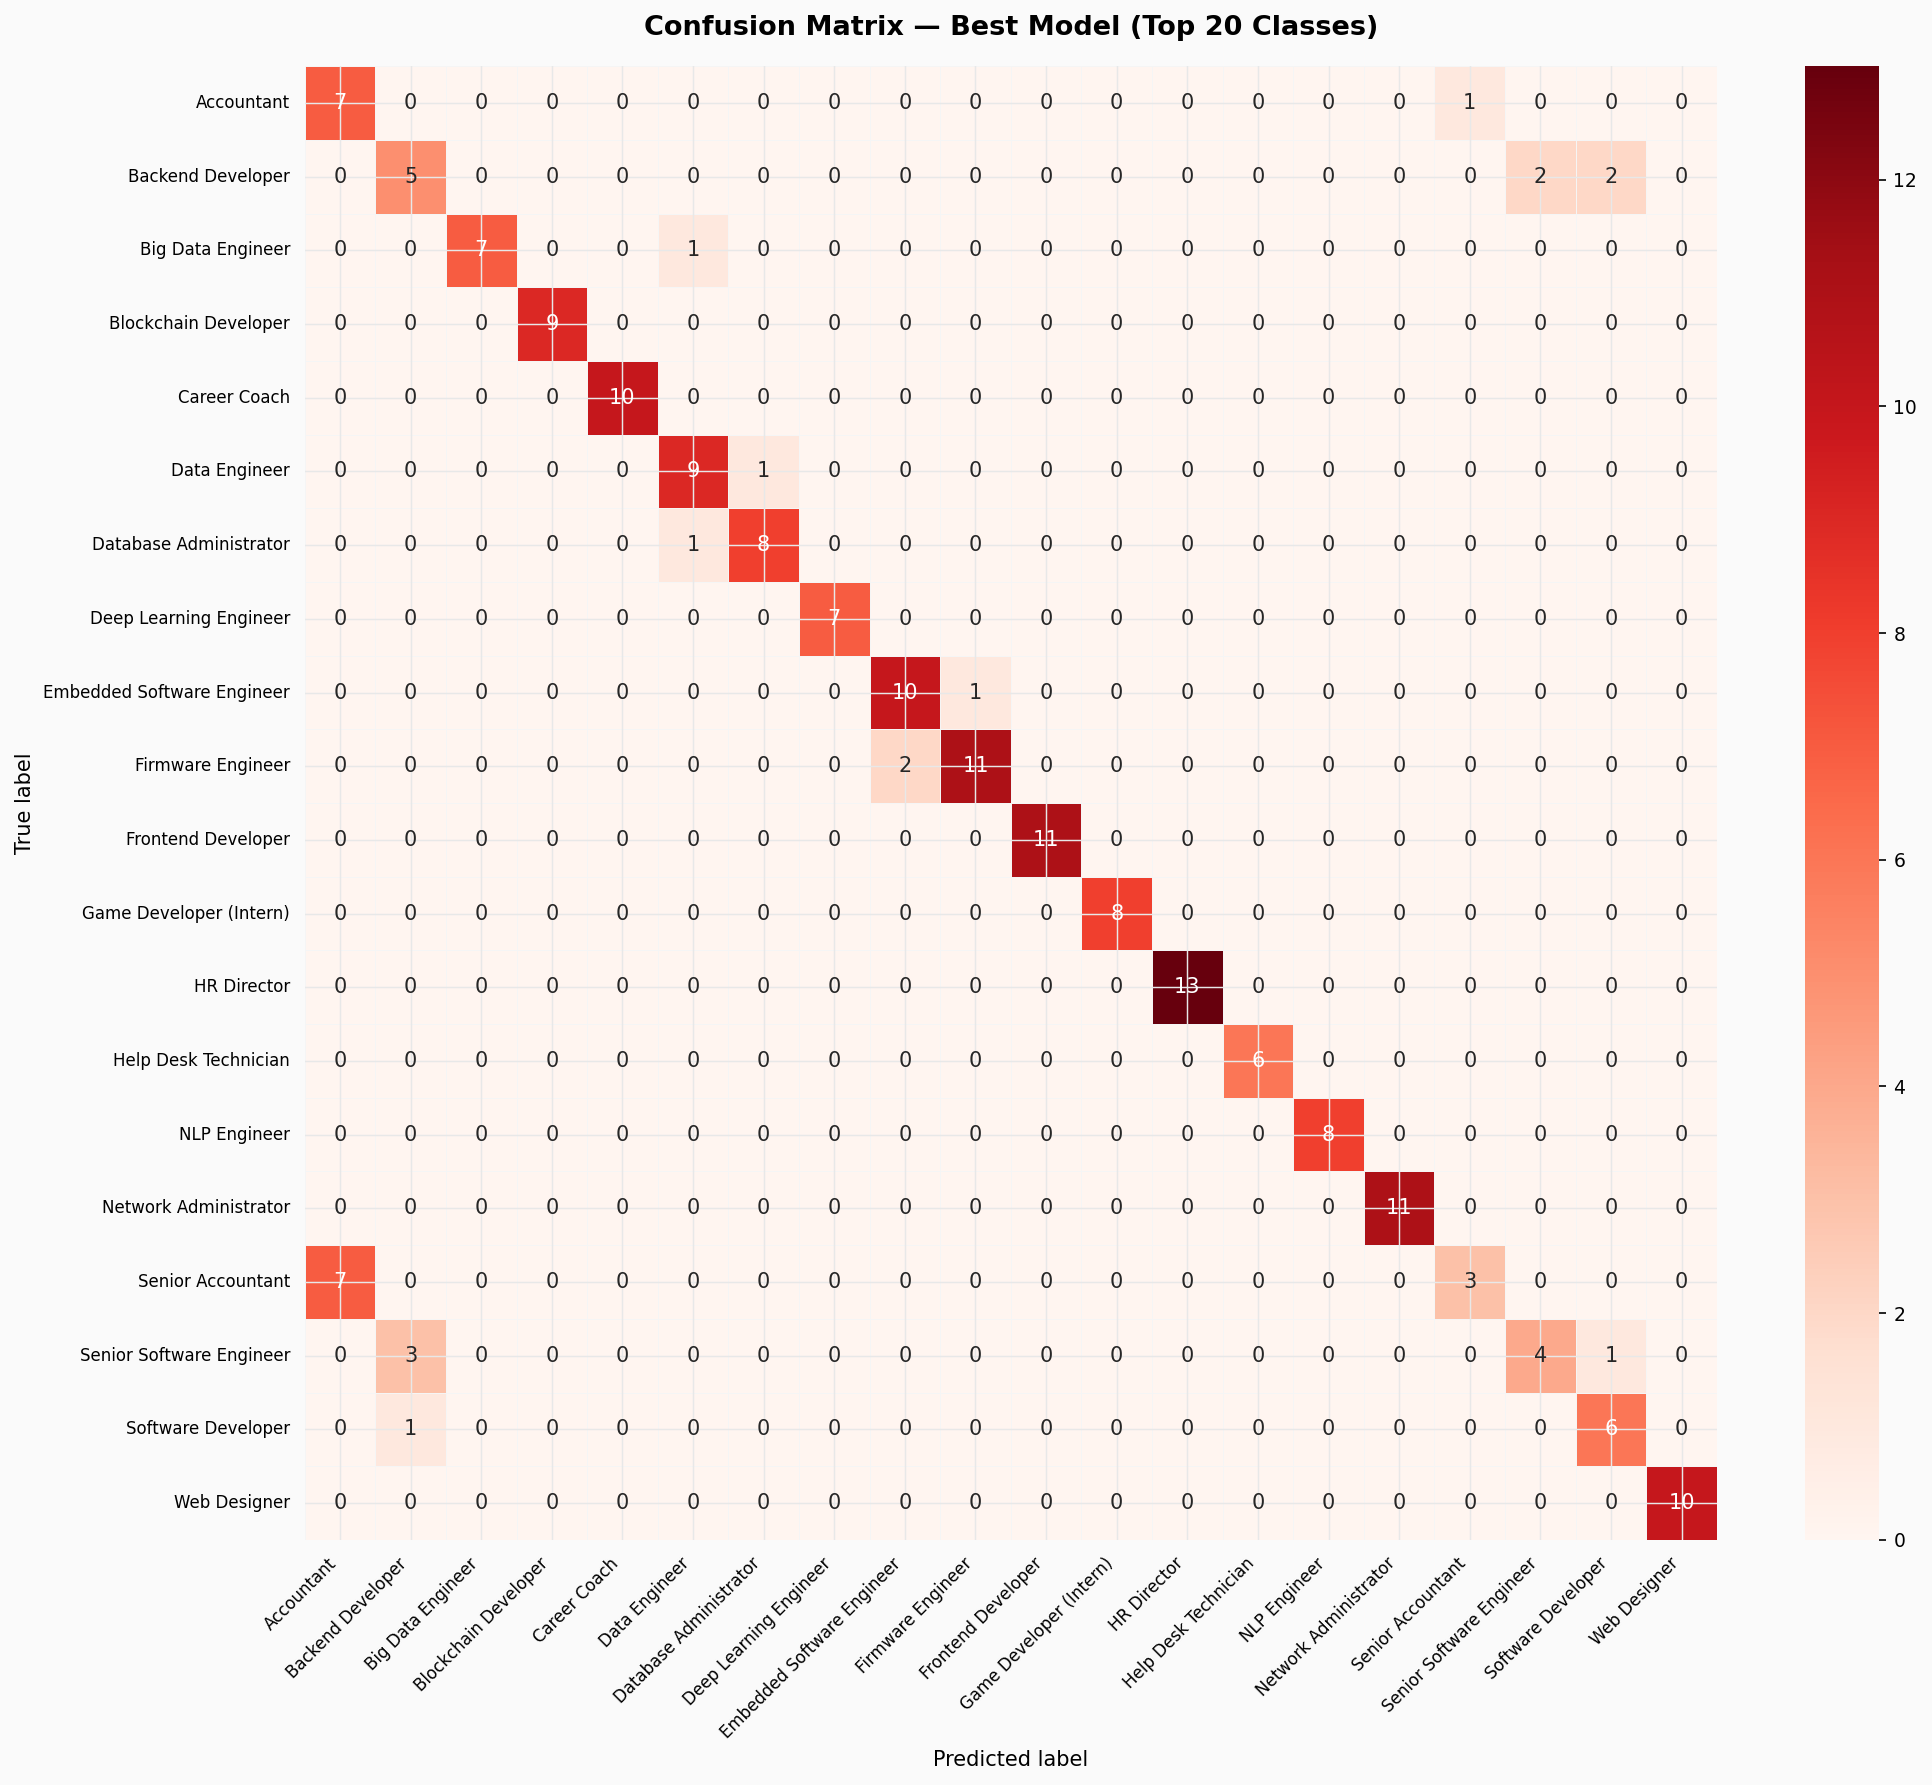

Saved: ../data/images/confusion_matrix_best_model.png


In [13]:
# reset_index pour aligner les index avant d'appliquer le masque (fix IndexingError)
y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(best_predictions).reset_index(drop=True)

top20_idx   = y_test_series.value_counts().head(20).index.tolist()
mask        = y_test_series.isin(top20_idx)
y_test_top  = y_test_series[mask].values
y_pred_top  = y_pred_series[mask].values
class_names = label_encoder.inverse_transform(sorted(top20_idx))

cm = confusion_matrix(y_test_top, y_pred_top, labels=sorted(top20_idx))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap=CMAP_HEAT,
    linewidths=0.3,
    linecolor='#f5f5f5',
    ax=ax
)
ax.set_xlabel('Predicted label', fontsize=10)
ax.set_ylabel('True label', fontsize=10)
ax.set_title('Confusion Matrix — Best Model (Top 20 Classes)',
             fontweight='bold', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
path = f'{IMG_DIR}/confusion_matrix_best_model.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 12. Image 9 — Feature Importance (Random Forest)

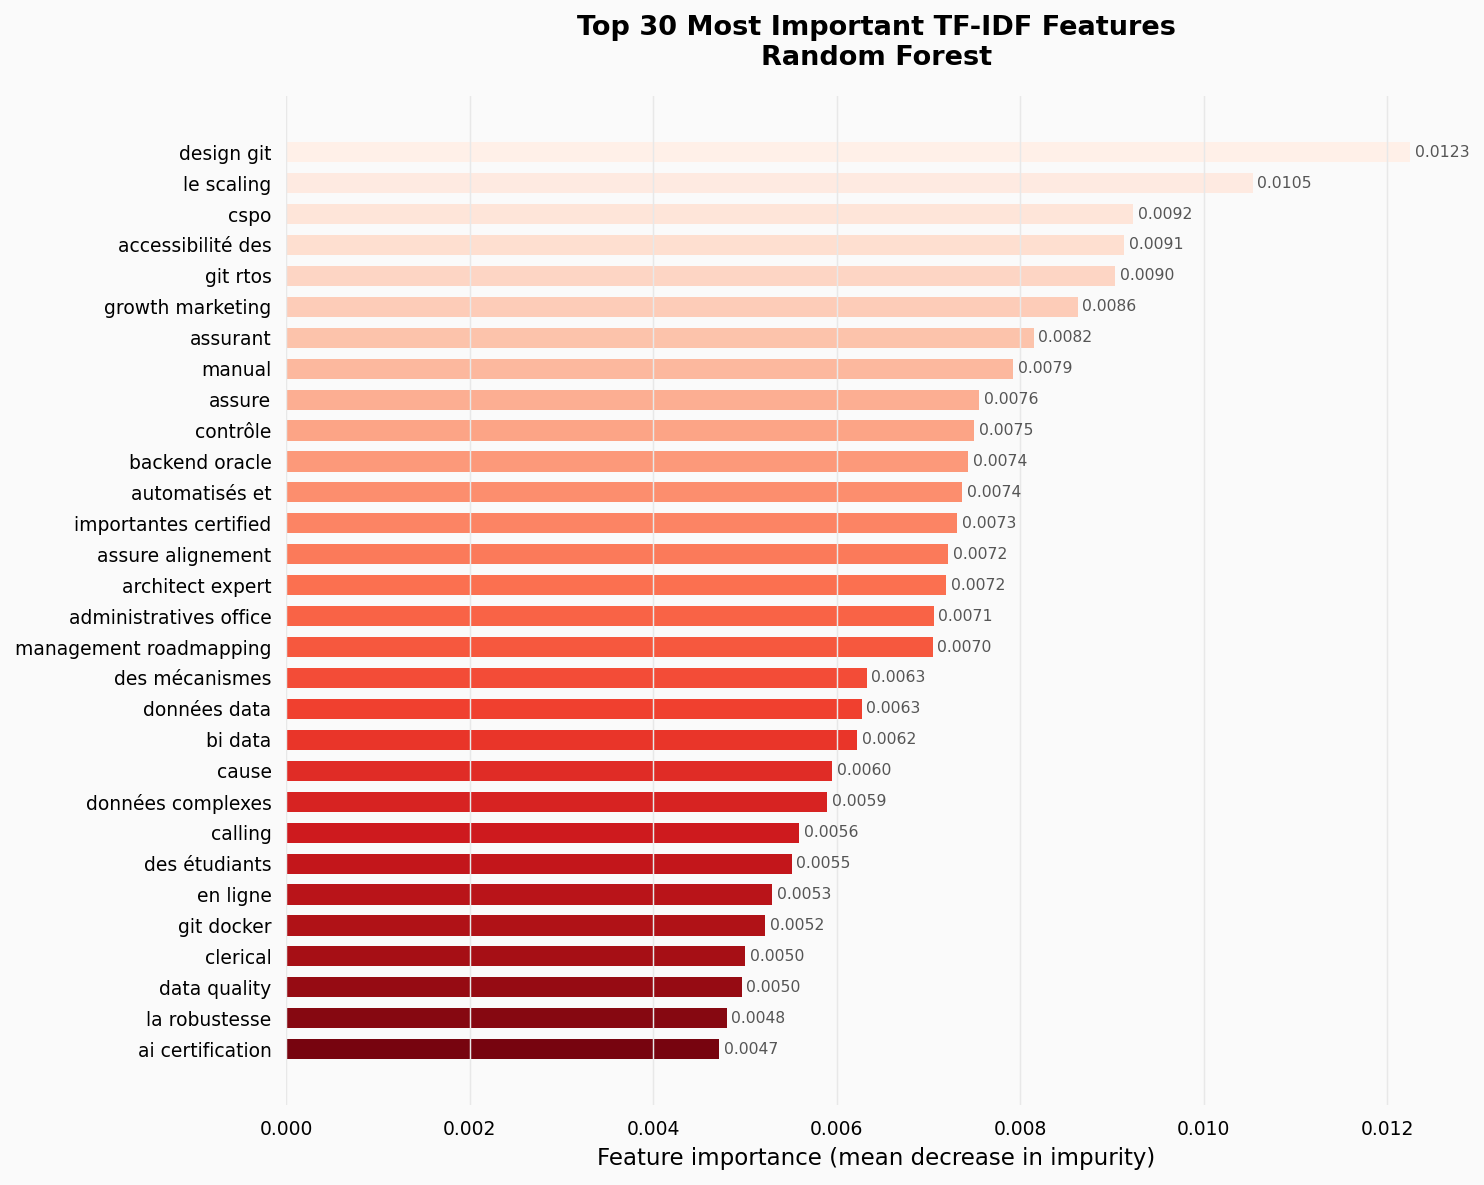

Saved: ../data/images/feature_importance.png


In [14]:
importances    = best_model.feature_importances_
tfidf_features = tfidf_vectorizer.get_feature_names_out()

tfidf_importances = importances[:len(tfidf_features)]
top_idx           = np.argsort(tfidf_importances)[::-1][:30]
top_features      = tfidf_features[top_idx]
top_values        = tfidf_importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('Reds_r', 30)
bars   = ax.barh(top_features[::-1], top_values[::-1],
                 color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, top_values[::-1]):
    ax.text(val + 0.00005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=7.5, color='#555')

ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Top 30 Most Important TF-IDF Features\nRandom Forest', fontweight='bold', pad=15)
ax.grid(axis='y', visible=False)

plt.tight_layout()
path = f'{IMG_DIR}/feature_importance.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 13. Image 10 — Top 20 Certifications Frequency

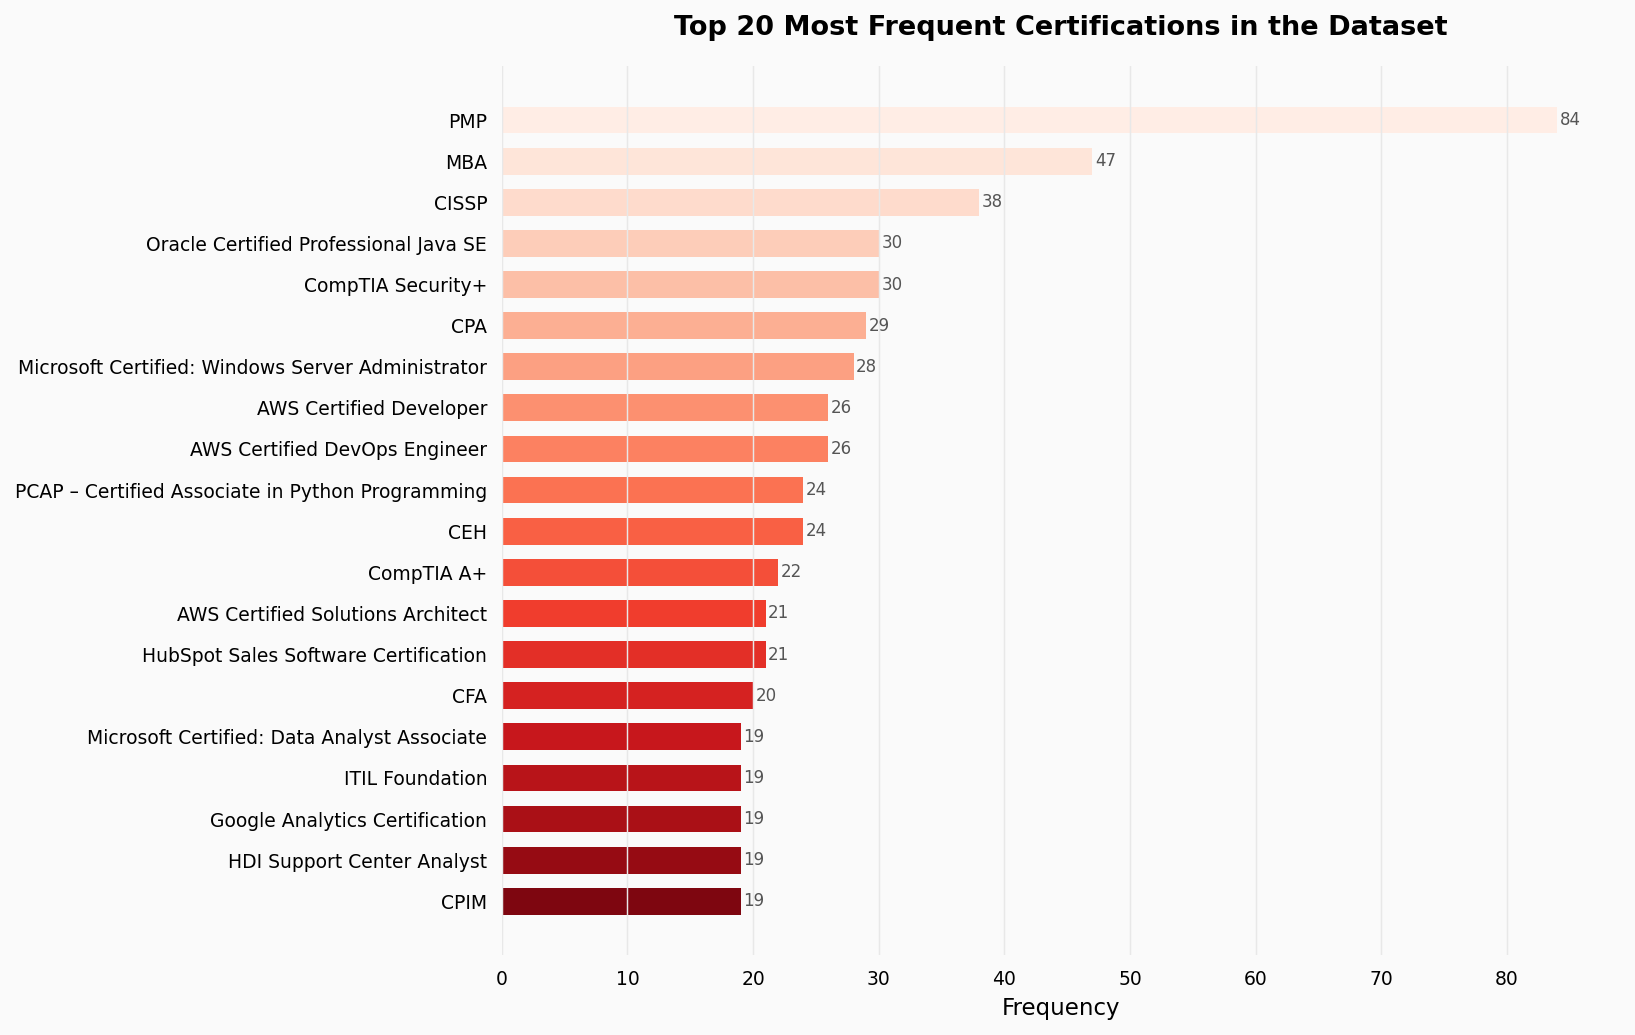

Saved: ../data/images/certifications_frequency.png


In [15]:
all_certs = []
for row in df['Certifications'].dropna():
    for cert in str(row).split(';'):
        c = cert.strip()
        if c:
            all_certs.append(c)

cert_counts = Counter(all_certs).most_common(20)
certs_df    = pd.DataFrame(cert_counts, columns=['Certification', 'Count'])

fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette('Reds_r', 20)
bars   = ax.barh(certs_df['Certification'][::-1], certs_df['Count'][::-1],
                 color=colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, certs_df['Count'][::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8, color='#555')

ax.set_xlabel('Frequency')
ax.set_title('Top 20 Most Frequent Certifications in the Dataset',
             fontweight='bold', pad=15)
ax.set_xlim(0, certs_df['Count'].max() + 5)
ax.grid(axis='y', visible=False)

plt.tight_layout()
path = f'{IMG_DIR}/certifications_frequency.png'
plt.savefig(path)
plt.show()
print(f'Saved: {path}')

## 14. Summary

In [16]:
saved = sorted(os.listdir(IMG_DIR))

print('=' * 55)
print('ALL IMAGES SAVED IN', os.path.abspath(IMG_DIR))
print('=' * 55)
for i, f in enumerate(saved, 1):
    size_kb = os.path.getsize(os.path.join(IMG_DIR, f)) / 1024
    print(f'  {i:02d}. {f:<45} {size_kb:6.1f} KB')
print('=' * 55)
print(f'Total: {len(saved)} images')

ALL IMAGES SAVED IN c:\Users\DELL\OneDrive\Bureau\Job-Roles-Prediction - Copie\data\images
  01. certifications_frequency.png                    93.0 KB
  02. class_balance.png                               41.7 KB
  03. confusion_matrix_best_model.png                216.8 KB
  04. feature_importance.png                         121.6 KB
  05. job_distribution.png                            85.4 KB
  06. model_comparison.png                           123.1 KB
  07. skills_frequency.png                            84.3 KB
  08. text_length_distribution.png                    51.9 KB
  09. tfidf_variance.png                              80.5 KB
  10. wordcloud_skills.png                           751.2 KB
Total: 10 images
